In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df = pd.read_csv("data/auto-mpg.csv")

In [3]:
df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.shape

(398, 9)

In [5]:
df.dropna(inplace=True)

In [6]:
df.columns.tolist()

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year',
 'origin',
 'car name']

In [7]:
x = df[["displacement"]]
y = df["mpg"]

In [8]:
x.shape

(398, 1)

In [9]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [10]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
y_linear_pred = linear_model.predict(x_test)
linear_mse = mean_squared_error(y_test,y_linear_pred)
linear_r2 = r2_score(y_test,y_linear_pred)

print("MSE",linear_mse)
print("R2",linear_r2)


MSE 18.102543998358946
R2 0.6633114869465596


In [11]:
degrees = [2,3,4,5]
results = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)

    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    poly_model = LinearRegression()

    poly_model.fit(x_train_poly,y_train)
    y_poly_pred = poly_model.predict(x_test_poly)

    mse = mean_squared_error(y_test,y_poly_pred)
    r2 = r2_score(y_test,y_poly_pred)

    results.append([degree,mse,r2])

    print("MSE",mse)
    print("R2",r2)

MSE 15.107353561080766
R2 0.7190189176110282
MSE 16.369649051540453
R2 0.6955415327884606
MSE 18.3987903102031
R2 0.657801613293364
MSE 20.99814570920854
R2 0.6094563031387298


In [12]:
print("Linear Regression")
print("MSE :", linear_mse)
print("R2 Score :", linear_r2)

for result in results:
    print(
        "Polynomial Degree", result[0],
        "MSE :", result[1],
        "R2 Score :", result[2]
    )

Linear Regression
MSE : 18.102543998358946
R2 Score : 0.6633114869465596
Polynomial Degree 2 MSE : 15.107353561080766 R2 Score : 0.7190189176110282
Polynomial Degree 3 MSE : 16.369649051540453 R2 Score : 0.6955415327884606
Polynomial Degree 4 MSE : 18.3987903102031 R2 Score : 0.657801613293364
Polynomial Degree 5 MSE : 20.99814570920854 R2 Score : 0.6094563031387298


c:\Users\Anandakrishnan VB\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


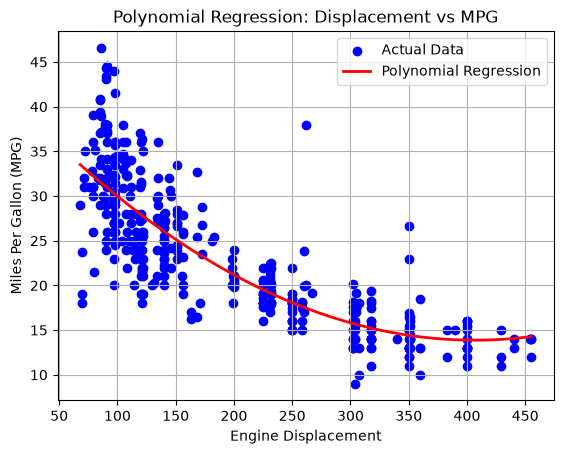

c:\Users\Anandakrishnan VB\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


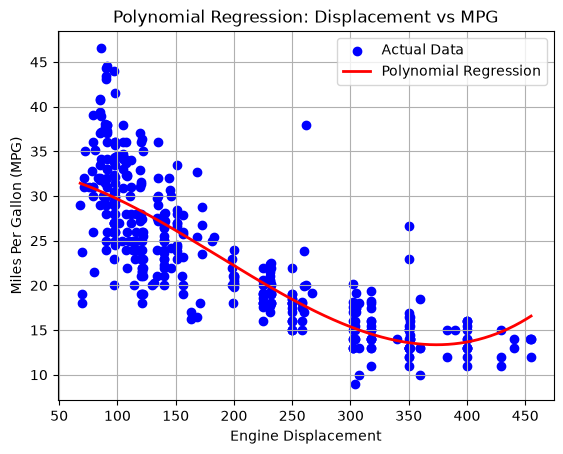

c:\Users\Anandakrishnan VB\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


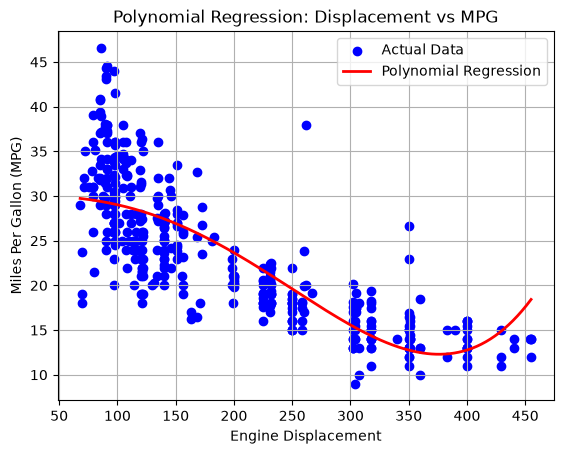

c:\Users\Anandakrishnan VB\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


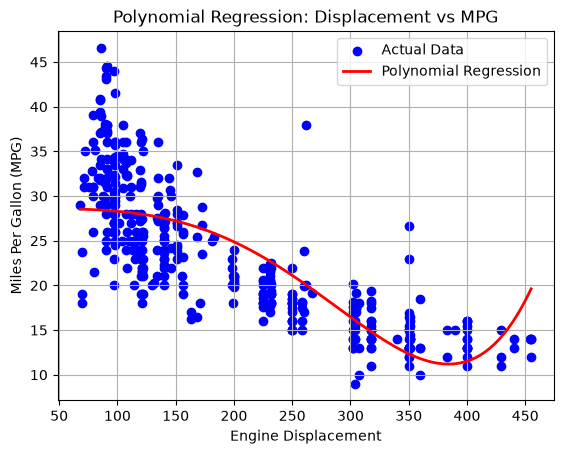

In [15]:
degrees = [2, 3, 4, 5]

for degree in degrees:

	poly = PolynomialFeatures(degree=degree)

	X_poly = poly.fit_transform(x)

	poly_model = LinearRegression()

	poly_model.fit(X_poly, y)


	# Create smooth X values for plotting
	X_plot = np.linspace(
	    x["displacement"].min(),
	    x["displacement"].max(),
	    300
	).reshape(-1, 1)


	# Transform X_plot into polynomial features
	X_plot_poly = poly.transform(X_plot)

	# Predict MPG
	y_plot = poly_model.predict(X_plot_poly)


	# Plot actual data
	plt.scatter(
	    x,
	    y,
	    color="blue",
	    label="Actual Data"
	)

	# Plot polynomial curve
	plt.plot(
	    X_plot,
	    y_plot,
	    color="red",
	    linewidth=2,
	    label="Polynomial Regression"
	)

	plt.xlabel("Engine Displacement")
	plt.ylabel("Miles Per Gallon (MPG)")
	plt.title("Polynomial Regression: Displacement vs MPG")
	plt.legend()
	plt.grid()
	plt.show()